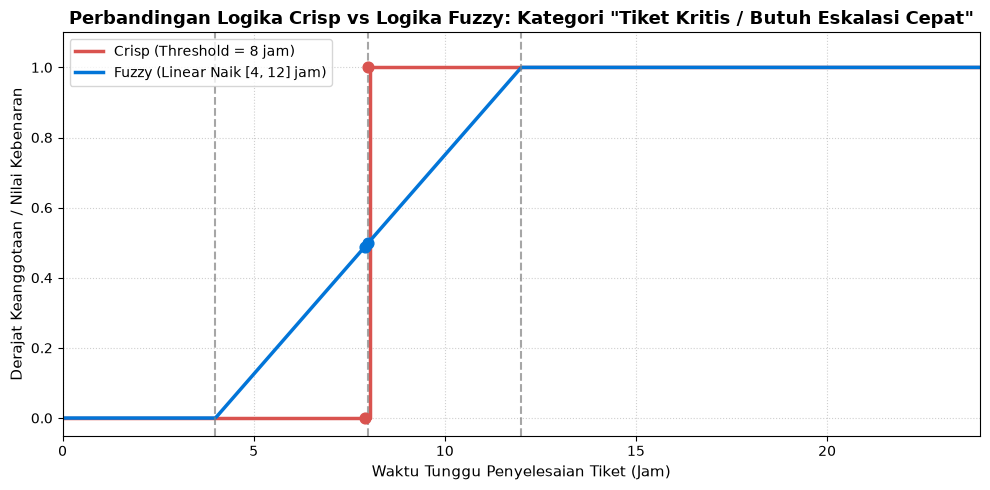

Waktu    | Crisp    | Fuzzy mu(x)  | Interpretasi Fuzzy
---------------------------------------------------------------------------
2.00     | 0.0      | 0.000        | Tingkat kekritisan 0.0%
4.00     | 0.0      | 0.000        | Tingkat kekritisan 0.0%
6.00     | 0.0      | 0.250        | Tingkat kekritisan 25.0%
7.90     | 0.0      | 0.488        | Tingkat kekritisan 48.8%
8.00     | 1.0      | 0.500        | Tingkat kekritisan 50.0%
8.10     | 1.0      | 0.512        | Tingkat kekritisan 51.2%
10.00    | 1.0      | 0.750        | Tingkat kekritisan 75.0%
12.00    | 1.0      | 1.000        | Tingkat kekritisan 100.0%
16.00    | 1.0      | 1.000        | Tingkat kekritisan 100.0%
24.00    | 1.0      | 1.000        | Tingkat kekritisan 100.0%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

#DEFINISI FUNGSI KARAKTERISTIK CRISP

def crisp_kritis(waktu, threshold=8.0):
    """
    Fungsi karakteristik crisp.
    Mengembalikan 1 jika waktu tunggu >= threshold,
    selain itu 0.
    """
    return np.where(waktu >= threshold, 1.0, 0.0)


#DEFINISI FUNGSI KEANGGOTAAN FUZZY

def fuzzy_kritis(waktu, a=4.0, b=12.0):
    """
    Fungsi keanggotaan fuzzy linear naik.
    - x <= a       : derajat kritis 0
    - a <= x <= b  : derajat (x - a) / (b - a)
    - x >= b       : derajat kritis 1
    """
    derajat = (waktu - a) / (b - a)
    return np.clip(derajat, 0.0, 1.0)


#GENERASI DATA SEMESTA PEMBICARAAN
# Domain waktu tunggu tiket dari 0 sampai 24 jam

waktu = np.linspace(0.0, 24.0, 500)

y_crisp = crisp_kritis(waktu, threshold=8.0)
y_fuzzy = fuzzy_kritis(waktu, a=4.0, b=12.0)


#4.VISUALISASI PERBANDINGAN

plt.figure(figsize=(10, 5))

# Plot Logika Crisp
plt.step(
    waktu,
    y_crisp,
    label='Crisp (Threshold = 8 jam)',
    color='#d9534f',
    linewidth=2.5,
    where='post'
)

# Plot Logika Fuzzy
plt.plot(
    waktu,
    y_fuzzy,
    label='Fuzzy (Linear Naik [4, 12] jam)',
    color='#0275d8',
    linewidth=2.5
)

# Penanda titik batas kritis
plt.axvline(
    x=4.0,
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.axvline(
    x=8.0,
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.axvline(
    x=12.0,
    color='gray',
    linestyle='--',
    alpha=0.7
)

# Titik batas Crisp
plt.scatter(
    [7.9, 8.0],
    [crisp_kritis(7.9), crisp_kritis(8.0)],
    color='#d9534f',
    zorder=5,
    s=60
)

# Titik batas Fuzzy
plt.scatter(
    [7.9, 8.0],
    [fuzzy_kritis(7.9), fuzzy_kritis(8.0)],
    color='#0275d8',
    zorder=5,
    s=60
)

plt.title(
    'Perbandingan Logika Crisp vs Logika Fuzzy: '
    'Kategori "Tiket Kritis / Butuh Eskalasi Cepat"',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Waktu Tunggu Penyelesaian Tiket (Jam)',
    fontsize=11
)

plt.ylabel(
    'Derajat Keanggotaan / Nilai Kebenaran',
    fontsize=11
)

plt.xlim(0, 24)
plt.ylim(-0.05, 1.1)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    loc='upper left',
    fontsize=10
)

plt.tight_layout()

plt.show()

#PENGUJIAN CRISP VS FUZZY

test_values = [2, 4, 6, 7.9, 8.0, 8.1, 10, 12, 16, 24]

print(f"{'Waktu':<8} | {'Crisp':<8} | {'Fuzzy mu(x)':<12} | {'Interpretasi Fuzzy'}")
print("-" * 75)

for val in test_values:
    c_val = float(crisp_kritis(val))
    f_val = float(fuzzy_kritis(val))

    interpretasi = f"Tingkat kekritisan {f_val * 100:.1f}%"

    print(
        f"{val:<8.2f} | "
        f"{c_val:<8.1f} | "
        f"{f_val:<12.3f} | "
        f"{interpretasi}"
    )